# Streetview Semantic Comfort Audit

This notebook follows mature street-view CV workflows: image QA, semantic segmentation, feature extraction, cluster-based typology, heat-stress modeling, and corridor intervention ranking.

In [1]:
from pathlib import Path
import os, warnings
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage import color, filters, measure, morphology, feature
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from IPython.display import display, Markdown
PROJECT = Path.cwd()
DATA = PROJECT / "data"
OUTPUTS = PROJECT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
print("Data files:", [p.name for p in sorted(DATA.iterdir())])

Data files: ['image_index.csv', 'images']


In [2]:
index = pd.read_csv(DATA / "image_index.csv")
display(index.head())
print(f"Images: {len(index)}, corridors: {index['corridor'].nunique()}")

,image,lon,lat,observed_heat_c,pedestrian_count,corridor
0,street_00.png,118.720,32.0,36.462092,168,A
1,street_01.png,118.726,32.0,39.532124,133,A
2,street_02.png,118.732,32.0,37.287687,253,A
3,street_03.png,118.738,32.0,37.422122,172,A
4,street_04.png,118.744,32.0,34.569227,257,A


Images: 30, corridors: 3


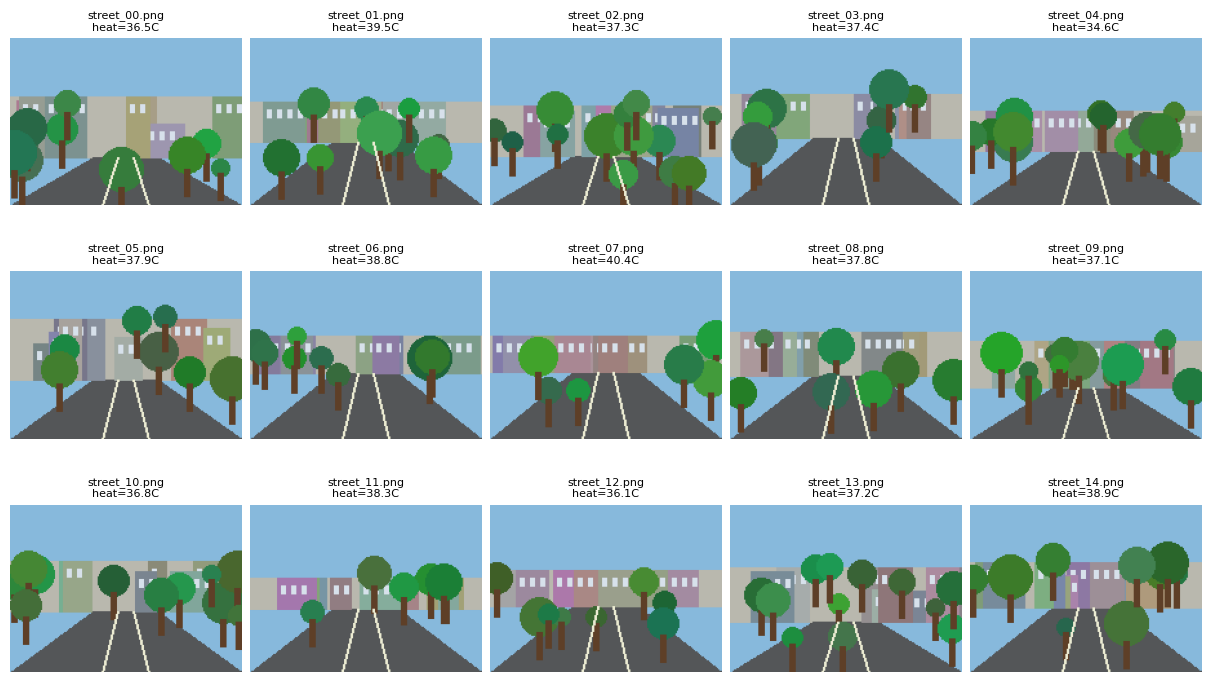

Saved outputs/streetview_sample_montage.png


In [3]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7), constrained_layout=True)
for ax, row in zip(axes.ravel(), index.head(15).itertuples(index=False)):
    img = Image.open(DATA / "images" / row.image)
    ax.imshow(img)
    ax.set_title(f"{row.image}\nheat={row.observed_heat_c:.1f}C", fontsize=8)
    ax.axis("off")
fig.savefig(OUTPUTS / "streetview_sample_montage.png", dpi=170)
plt.show()
print("Saved outputs/streetview_sample_montage.png")

In [4]:
def segment_image(path):
    arr = np.asarray(Image.open(path).convert("RGB")) / 255.0
    hsv = color.rgb2hsv(arr)
    gray = color.rgb2gray(arr)
    vegetation = (hsv[..., 0] > 0.20) & (hsv[..., 0] < 0.46) & (hsv[..., 1] > 0.22) & (hsv[..., 2] > 0.18)
    sky = (hsv[..., 0] > 0.50) & (hsv[..., 0] < 0.68) & (hsv[..., 1] > 0.12) & (hsv[..., 2] > 0.45)
    road = (gray < 0.43) & (~vegetation) & (~sky)
    facade = ~(vegetation | sky | road)
    vegetation = morphology.remove_small_objects(vegetation, 16)
    sky = morphology.remove_small_objects(sky, 24)
    road = morphology.remove_small_objects(road, 24)
    edges = feature.canny(gray, sigma=1.2)
    return arr, {"vegetation": vegetation, "sky": sky, "road": road, "facade": facade, "edges": edges}

arr, masks = segment_image(DATA / "images" / index.iloc[0]["image"])
print({name: int(mask.sum()) for name, mask in masks.items()})

{'vegetation': 4837, 'sky': 9360, 'road': 3983, 'facade': 5204, 'edges': 1474}


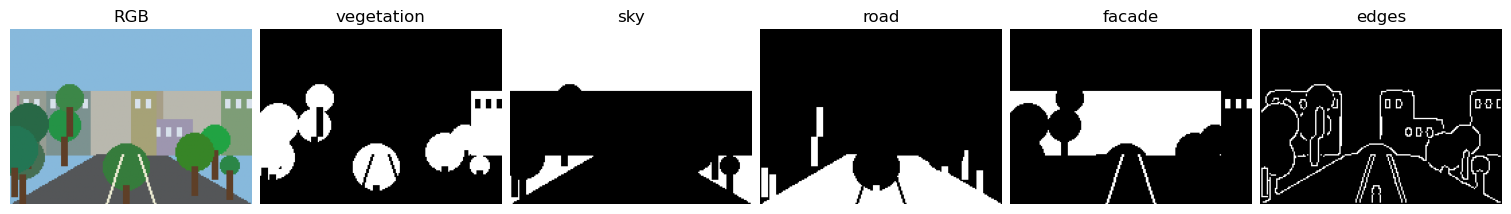

Saved segmentation example for street_00.png


In [5]:
sample = index.iloc[0]["image"]
arr, masks = segment_image(DATA / "images" / sample)
fig, axes = plt.subplots(1, 6, figsize=(15, 3), constrained_layout=True)
axes[0].imshow(arr)
axes[0].set_title("RGB")
for ax, name in zip(axes[1:], ["vegetation", "sky", "road", "facade", "edges"]):
    ax.imshow(masks[name], cmap="gray")
    ax.set_title(name)
for ax in axes:
    ax.axis("off")
fig.savefig(OUTPUTS / "semantic_masks_example.png", dpi=170)
plt.show()
print(f"Saved segmentation example for {sample}")

In [6]:
records = []
for row in index.itertuples(index=False):
    arr, masks = segment_image(DATA / "images" / row.image)
    total = arr.shape[0] * arr.shape[1]
    veg = masks["vegetation"]
    sky = masks["sky"]
    facade = masks["facade"]
    labels = measure.label(veg)
    props = measure.regionprops(labels)
    canopy_objects = len([p for p in props if p.area >= 20])
    records.append({
        "image": row.image,
        "green_view": veg.sum() / total,
        "sky_view": sky.sum() / total,
        "road_view": masks["road"].sum() / total,
        "facade_view": facade.sum() / total,
        "edge_density": masks["edges"].sum() / total,
        "canopy_objects": canopy_objects,
        "observed_heat_c": row.observed_heat_c,
        "pedestrian_count": row.pedestrian_count,
        "corridor": row.corridor,
    })
metrics = pd.DataFrame(records)
display(metrics.head().round(3))
display(metrics.describe().round(3))

,image,green_view,sky_view,road_view,facade_view,edge_density,canopy_objects,observed_heat_c,pedestrian_count,corridor
0,street_00.png,0.207,0.400,0.170,0.222,0.063,3,36.462,168,A
1,street_01.png,0.175,0.449,0.216,0.159,0.058,5,39.532,133,A
2,street_02.png,0.194,0.502,0.188,0.116,0.070,7,37.288,253,A
3,street_03.png,0.174,0.435,0.251,0.140,0.053,3,37.422,172,A
4,street_04.png,0.151,0.501,0.230,0.118,0.053,3,34.569,257,A


,green_view,sky_view,road_view,facade_view,edge_density,canopy_objects,observed_heat_c,pedestrian_count
count,30.000,30.000,30.000,30.000,30.000,30.000,30.000,30.000
mean,0.159,0.445,0.220,0.176,0.060,4.967,37.425,173.533
std,0.039,0.053,0.028,0.057,0.006,1.903,1.359,70.730
min,0.079,0.304,0.170,0.107,0.052,2.000,34.569,65.000
25%,0.135,0.405,0.203,0.136,0.056,3.000,36.535,112.250
50%,0.171,0.455,0.218,0.161,0.059,5.000,37.167,159.500
75%,0.187,0.485,0.242,0.200,0.063,6.000,38.238,250.500
max,0.230,0.530,0.271,0.335,0.072,10.000,40.417,278.000


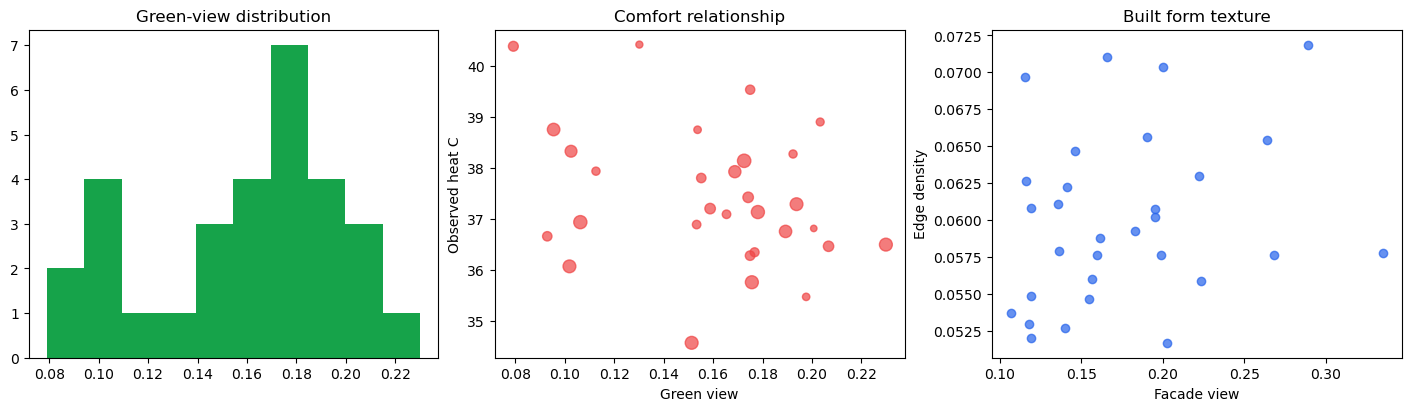

green_view         -0.309
pedestrian_count   -0.297
canopy_objects     -0.096
edge_density       -0.023
sky_view            0.060
facade_view         0.104
road_view           0.106
observed_heat_c     1.000
Name: observed_heat_c, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].hist(metrics["green_view"], bins=10, color="#16a34a")
axes[0].set_title("Green-view distribution")
axes[1].scatter(metrics["green_view"], metrics["observed_heat_c"], s=metrics["pedestrian_count"] / 3, alpha=0.7, color="#ef4444")
axes[1].set_xlabel("Green view")
axes[1].set_ylabel("Observed heat C")
axes[1].set_title("Comfort relationship")
axes[2].scatter(metrics["facade_view"], metrics["edge_density"], color="#2563eb", alpha=0.7)
axes[2].set_xlabel("Facade view")
axes[2].set_ylabel("Edge density")
axes[2].set_title("Built form texture")
fig.savefig(OUTPUTS / "streetscape_metric_diagnostics.png", dpi=170)
plt.show()
display(metrics.corr(numeric_only=True)["observed_heat_c"].sort_values().round(3))

In [8]:
features = ["green_view", "sky_view", "road_view", "facade_view", "edge_density", "canopy_objects"]
X = StandardScaler().fit_transform(metrics[features])
kmeans = KMeans(n_clusters=4, random_state=4, n_init=20)
metrics["typology"] = kmeans.fit_predict(X)
cluster_summary = metrics.groupby("typology")[features + ["observed_heat_c"]].mean().round(3)
display(cluster_summary)

,green_view,sky_view,road_view,facade_view,edge_density,canopy_objects,observed_heat_c
typology,,,,,,,
0,0.183,0.438,0.236,0.143,0.059,3.900,37.530
1,0.182,0.440,0.189,0.188,0.064,6.429,37.191
2,0.152,0.354,0.205,0.289,0.063,5.750,37.590
3,0.118,0.496,0.233,0.153,0.056,4.667,37.417


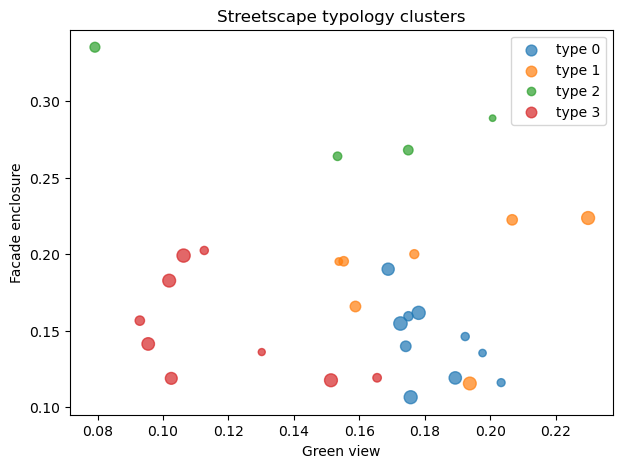

Saved outputs/streetscape_typology_clusters.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for typology, sub in metrics.groupby("typology"):
    ax.scatter(sub["green_view"], sub["facade_view"], s=sub["pedestrian_count"] / 3, label=f"type {typology}", alpha=0.7)
ax.set_xlabel("Green view")
ax.set_ylabel("Facade enclosure")
ax.set_title("Streetscape typology clusters")
ax.legend()
fig.savefig(OUTPUTS / "streetscape_typology_clusters.png", dpi=170)
plt.show()
print("Saved outputs/streetscape_typology_clusters.png")

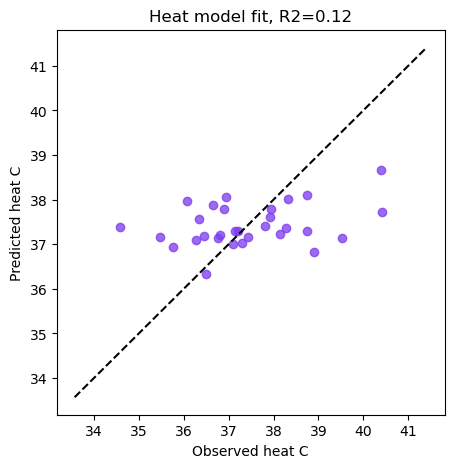

green_view       -12.177
sky_view          -0.864
facade_view        0.664
edge_density      31.616
canopy_objects    -0.091
Name: heat_model_coef, dtype: float64

In [10]:
model_features = ["green_view", "sky_view", "facade_view", "edge_density", "canopy_objects"]
model = LinearRegression().fit(metrics[model_features], metrics["observed_heat_c"])
metrics["predicted_heat_c"] = model.predict(metrics[model_features])
coef = pd.Series(model.coef_, index=model_features, name="heat_model_coef")
r2 = r2_score(metrics["observed_heat_c"], metrics["predicted_heat_c"])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(metrics["observed_heat_c"], metrics["predicted_heat_c"], color="#7c3aed", alpha=0.75)
lims = [metrics["observed_heat_c"].min() - 1, metrics["observed_heat_c"].max() + 1]
ax.plot(lims, lims, color="black", linestyle="--")
ax.set_xlabel("Observed heat C")
ax.set_ylabel("Predicted heat C")
ax.set_title(f"Heat model fit, R2={r2:.2f}")
fig.savefig(OUTPUTS / "heat_model_fit.png", dpi=170)
plt.show()
display(coef.round(3))

In [11]:
metrics["comfort_priority"] = (
    metrics["predicted_heat_c"].rank(pct=True)
    + (1 - metrics["green_view"]).rank(pct=True)
    + metrics["pedestrian_count"].rank(pct=True)
)
priority = metrics.sort_values("comfort_priority", ascending=False).head(10)
display(priority[["image", "corridor", "green_view", "predicted_heat_c", "pedestrian_count", "comfort_priority"]].round(3))

,image,corridor,green_view,predicted_heat_c,pedestrian_count,comfort_priority
18,street_18.png,B,0.106,38.066,270,2.733
6,street_06.png,A,0.095,38.103,243,2.633
12,street_12.png,B,0.102,37.971,254,2.567
23,street_23.png,C,0.079,38.675,151,2.500
11,street_11.png,B,0.103,38.017,217,2.400
29,street_29.png,C,0.093,37.872,137,2.200
4,street_04.png,A,0.151,37.386,257,2.167
17,street_17.png,B,0.173,37.239,278,1.933
5,street_05.png,A,0.169,37.618,229,1.900
28,street_28.png,C,0.113,37.784,104,1.833


,scenes,mean_green,mean_heat,pedestrians,priority
corridor,,,,,
B,10,0.159,37.381,1994,1.588
A,10,0.162,37.378,1783,1.545
C,10,0.157,37.516,1429,1.517


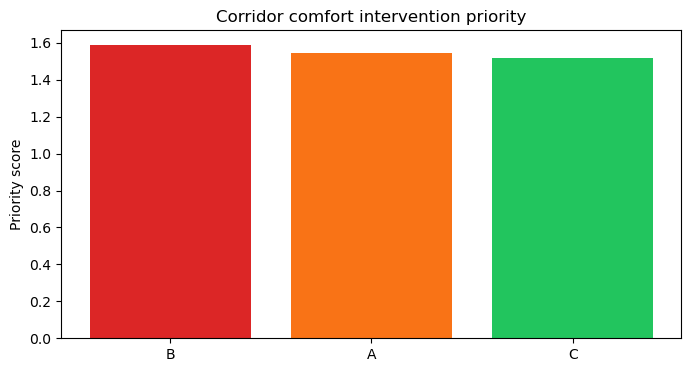

In [12]:
corridor = metrics.groupby("corridor").agg(
    scenes=("image", "count"),
    mean_green=("green_view", "mean"),
    mean_heat=("predicted_heat_c", "mean"),
    pedestrians=("pedestrian_count", "sum"),
    priority=("comfort_priority", "mean"),
).sort_values("priority", ascending=False)
display(corridor.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(corridor.index, corridor["priority"], color=["#dc2626", "#f97316", "#22c55e"][:len(corridor)])
ax.set_title("Corridor comfort intervention priority")
ax.set_ylabel("Priority score")
fig.savefig(OUTPUTS / "corridor_priority.png", dpi=170)
plt.show()

In [13]:
intervention = metrics.copy()
intervention["green_view_after"] = np.where(intervention["comfort_priority"] >= intervention["comfort_priority"].quantile(0.75), np.minimum(0.65, intervention["green_view"] + 0.14), intervention["green_view"])
after_features = intervention[model_features].copy()
after_features["green_view"] = intervention["green_view_after"]
intervention["heat_after_c"] = model.predict(after_features)
intervention["heat_reduction_c"] = intervention["predicted_heat_c"] - intervention["heat_after_c"]
display(intervention.sort_values("heat_reduction_c", ascending=False)[["image", "corridor", "green_view", "green_view_after", "heat_reduction_c"]].head(10).round(3))

,image,corridor,green_view,green_view_after,heat_reduction_c
4,street_04.png,A,0.151,0.291,1.705
17,street_17.png,B,0.173,0.313,1.705
23,street_23.png,C,0.079,0.219,1.705
29,street_29.png,C,0.093,0.233,1.705
11,street_11.png,B,0.103,0.243,1.705
6,street_06.png,A,0.095,0.235,1.705
18,street_18.png,B,0.106,0.246,1.705
12,street_12.png,B,0.102,0.242,1.705
2,street_02.png,A,0.194,0.194,0.000
7,street_07.png,A,0.130,0.130,0.000


In [14]:
metrics.to_csv(OUTPUTS / "streetview_image_metrics.csv", index=False)
corridor.to_csv(OUTPUTS / "corridor_priority_summary.csv")
intervention.to_csv(OUTPUTS / "street_greening_intervention.csv", index=False)
print("Exported files:")
for path in sorted(OUTPUTS.iterdir()):
    print(f"- {path.name} ({path.stat().st_size} bytes)")

Exported files:
- corridor_priority.png (25537 bytes)
- corridor_priority_summary.csv (243 bytes)
- heat_model_fit.png (46053 bytes)
- semantic_masks_example.png (132693 bytes)
- street_greening_intervention.csv (6698 bytes)
- streetscape_metric_diagnostics.png (101605 bytes)
- streetscape_typology_clusters.png (63501 bytes)
- streetview_image_metrics.csv (5291 bytes)
- streetview_sample_montage.png (260493 bytes)


In [15]:
top_corridor = corridor.index[0]
display(Markdown(f'''## Case conclusion

Corridor **{top_corridor}** is the highest intervention priority after combining image-derived heat exposure, low green-view, and pedestrian volume. The regression model reaches **R2={r2:.2f}** on the bundled audit set, and the intervention table estimates cooling benefits from targeted greening.
'''))

## Case conclusion

Corridor **B** is the highest intervention priority after combining image-derived heat exposure, low green-view, and pedestrian volume. The regression model reaches **R2=0.12** on the bundled audit set, and the intervention table estimates cooling benefits from targeted greening.
